# Ultrasonic Material Classification — Analysis & Modelling

**Dataset:** `dataset_version1.csv` (cardboard, wood) + `dataset_version2.csv` (wall, metal)  
**Goal:** Per-distance RandomForest classifiers that identify material from ultrasonic echo features  
**Approach:** Merge → EDA → Feature selection → Per-distance training → Evaluation → Persist

In [2]:
import subprocess
import sys

# Install all required dependencies
dependencies = [
    'pandas',
    'numpy',
    'scikit-learn',
    'joblib',
    'matplotlib',
    'seaborn',
    'xgboost',
    'jupyter'
]

for package in dependencies:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

print("All dependencies installed successfully!")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached notebook-7.5.5-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.5.6-py3-none-any.whl.metadata (16 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyter_server-2.17.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached bleach-


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [3]:
import warnings
warnings.filterwarnings('ignore')

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

---
## Phase 1 — Data Loading & Sanity Check

In [4]:
df1 = pd.read_csv('dataset_version1.csv')
df2 = pd.read_csv('dataset_version2.csv')

df = pd.concat([df1, df2], ignore_index=True)

# Drop target_distance_cm — distance_cm (sensor reading) is the feature we keep
df.drop(columns=['target_distance_cm'], inplace=True)

print(f'Combined shape : {df.shape}')
print(f'Classes        : {df["label"].value_counts().to_dict()}')
print(f'Null values    : {df.isnull().sum().sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print()
display(df.dtypes.to_frame('dtype').T)
display(df.describe().round(3))

Combined shape : (38000, 21)
Classes        : {'cardboard': 9500, 'wood': 9500, 'wall': 9500, 'metal': 9500}
Null values    : 0
Duplicate rows : 0



,distance_cm,snr,confidence,kurtosis,skewness,rms,zero_crossing_rate,peak_to_peak,pulse_width_us,rise_time_us,...,echo_area,crest_factor,spectral_centroid,spectral_crest,psd_energy,spectral_entropy,dominant_freq_hz,target_strength_dB,echo_noise_ratio,label
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,str


,distance_cm,snr,confidence,kurtosis,skewness,rms,zero_crossing_rate,peak_to_peak,pulse_width_us,rise_time_us,fall_time_us,echo_area,crest_factor,spectral_centroid,spectral_crest,psd_energy,spectral_entropy,dominant_freq_hz,target_strength_dB,echo_noise_ratio
count,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,38000.000,3.800000e+04,38000.000,38000.000,38000.000,38000.000
mean,110.165,21.386,1.000,-0.826,0.342,1944.377,0.068,2905.164,865.681,464.319,298.886,99169.963,1.729,4685.426,21.565,1.783451e+08,0.644,512.179,21.827,21.386
std,54.832,25.900,0.008,0.916,0.447,1912.709,0.055,3105.881,298.110,149.791,158.833,50720.098,0.171,600.821,5.357,2.764247e+08,0.060,268.991,9.001,25.900
min,20.000,2.060,0.369,-1.569,-0.254,240.310,0.009,409.240,166.650,33.330,77.770,28212.900,1.452,2483.400,8.050,1.300782e+06,0.475,351.600,6.270,2.060
25%,60.300,4.160,1.000,-1.296,0.036,521.287,0.029,741.332,766.590,455.510,211.090,48288.850,1.613,4280.875,19.927,9.452421e+06,0.601,351.600,12.390,4.160
50%,110.100,14.010,1.000,-1.154,0.196,1466.450,0.048,1929.495,922.130,499.950,277.750,97644.350,1.694,4726.500,23.036,8.257510e+07,0.633,351.600,22.930,14.010
75%,159.300,24.750,1.000,-0.771,0.496,2093.360,0.081,2969.020,1022.120,555.500,366.630,135404.375,1.793,5134.425,25.263,1.680353e+08,0.680,703.200,27.870,24.750
max,201.600,129.750,1.000,4.142,2.164,9128.170,0.267,13851.990,2766.390,922.130,1866.480,263839.900,2.506,6657.000,32.350,1.392255e+09,0.768,1758.000,42.260,129.750


In [5]:
# Encode labels to integers for XGBoost compatibility; keep mapping for later
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
CLASS_NAMES = list(le.classes_)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

Label encoding: {'cardboard': np.int64(0), 'metal': np.int64(1), 'wall': np.int64(2), 'wood': np.int64(3)}


---
## Phase 2 — Exploratory Data Analysis

### 2.1 Class Distribution

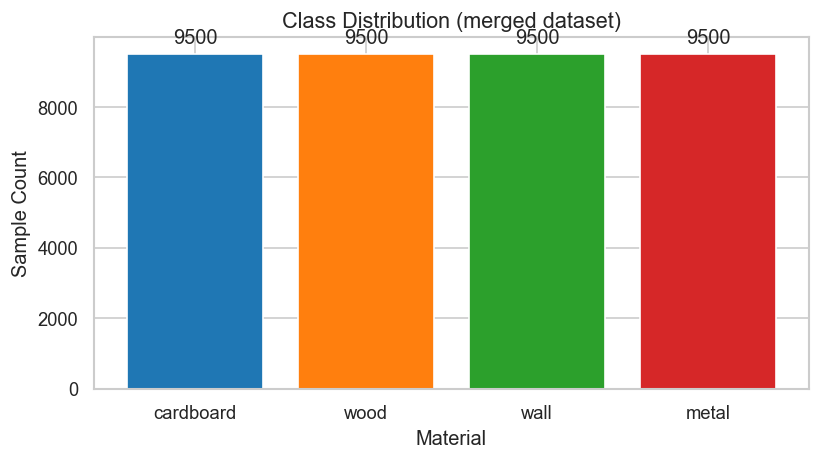

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('tab10', len(counts)))
ax.bar_label(bars, fmt='%d', padding=4)
ax.set_title('Class Distribution (merged dataset)', fontsize=13)
ax.set_xlabel('Material')
ax.set_ylabel('Sample Count')
plt.tight_layout()
plt.show()

### 2.2 Distance Distribution per Class

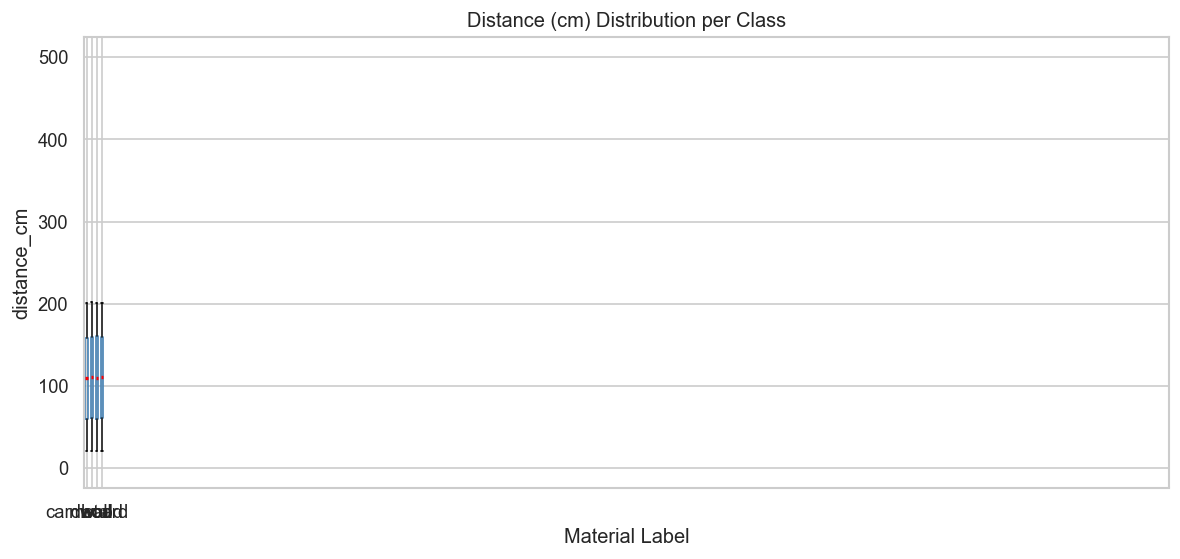


Samples per (distance bucket × material):


label,cardboard,metal,wall,wood
dist_bucket,,,,
20,500,500,500,500
30,500,500,500,500
40,500,500,502,500
50,500,500,656,617
60,500,501,347,385
70,500,617,495,554
80,500,430,500,446
90,515,456,500,498
100,485,496,504,500


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
palette = dict(zip(CLASS_NAMES, sns.color_palette('tab10', len(CLASS_NAMES))))
for label in CLASS_NAMES:
    subset = df[df['label'] == label]['distance_cm']
    ax.plot(sorted(subset.unique()), [subset[df['distance_cm'] == d].count()
                                      for d in sorted(subset.unique())],
            alpha=0.0)  # invisible — just to force legend

df.boxplot(column='distance_cm', by='label', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2),
           patch_artist=False)
ax.set_title('Distance (cm) Distribution per Class')
ax.set_xlabel('Material Label')
ax.set_ylabel('distance_cm')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Show sample counts per (label, target distance) to confirm coverage
import math
df['dist_bucket'] = (df['distance_cm'].round(0) // 10 * 10).astype(int)
pivot = df.pivot_table(index='dist_bucket', columns='label', values='distance_cm', aggfunc='count')
print('\nSamples per (distance bucket × material):')
display(pivot)

### 2.3 Feature Distributions by Class

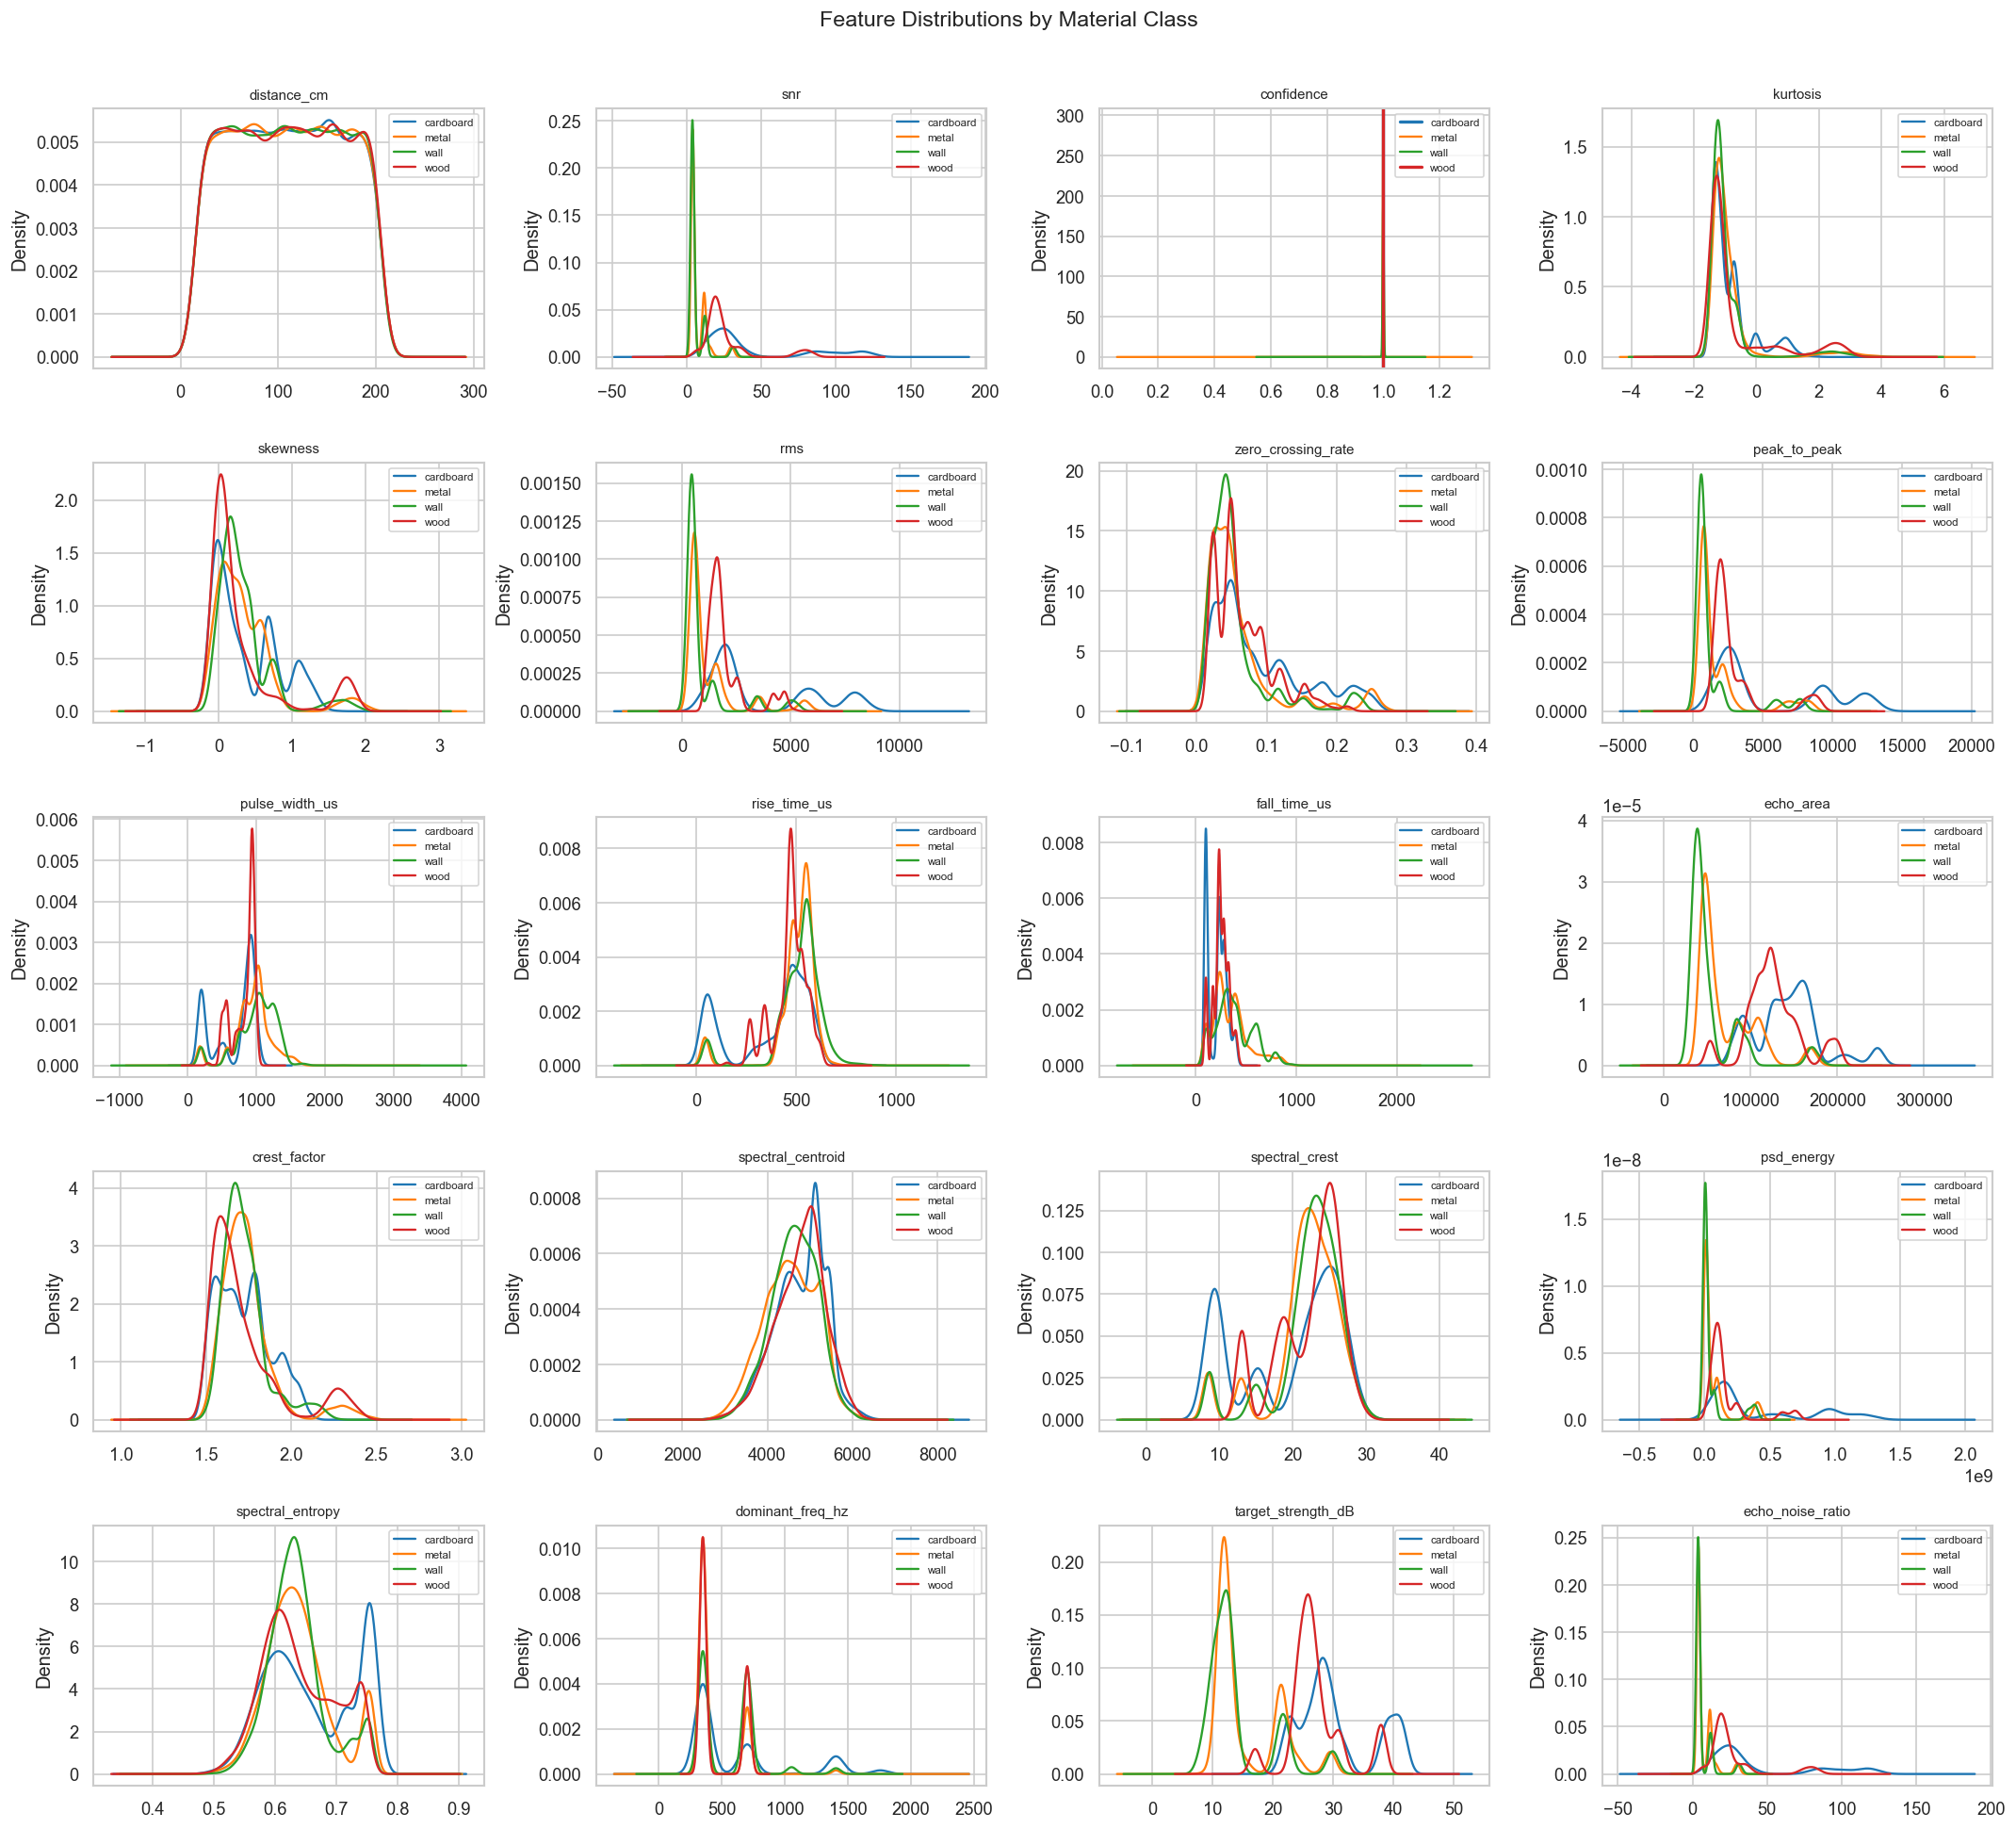

In [8]:
FEATURE_COLS = [c for c in df.columns if c not in ('label', 'label_enc', 'dist_bucket')]

# Identify zero-variance features (constant across all rows — KDE fails on these)
zero_var_feats = [f for f in FEATURE_COLS if df[f].std() == 0]
if zero_var_feats:
    print(f'Zero-variance features (excluded from KDE): {zero_var_feats}')

n_features = len(FEATURE_COLS)
ncols = 4
nrows = math.ceil(n_features / ncols)

palette = sns.color_palette('tab10', len(CLASS_NAMES))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for j, label in enumerate(CLASS_NAMES):
        subset = df[df['label'] == label][feat].dropna()
        if subset.std() == 0:
            ax.axvline(subset.iloc[0], color=palette[j], linewidth=2, label=label)
        else:
            subset.plot.kde(ax=ax, label=label, color=palette[j], linewidth=1.4)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Material Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 2.4 Correlation Heatmap

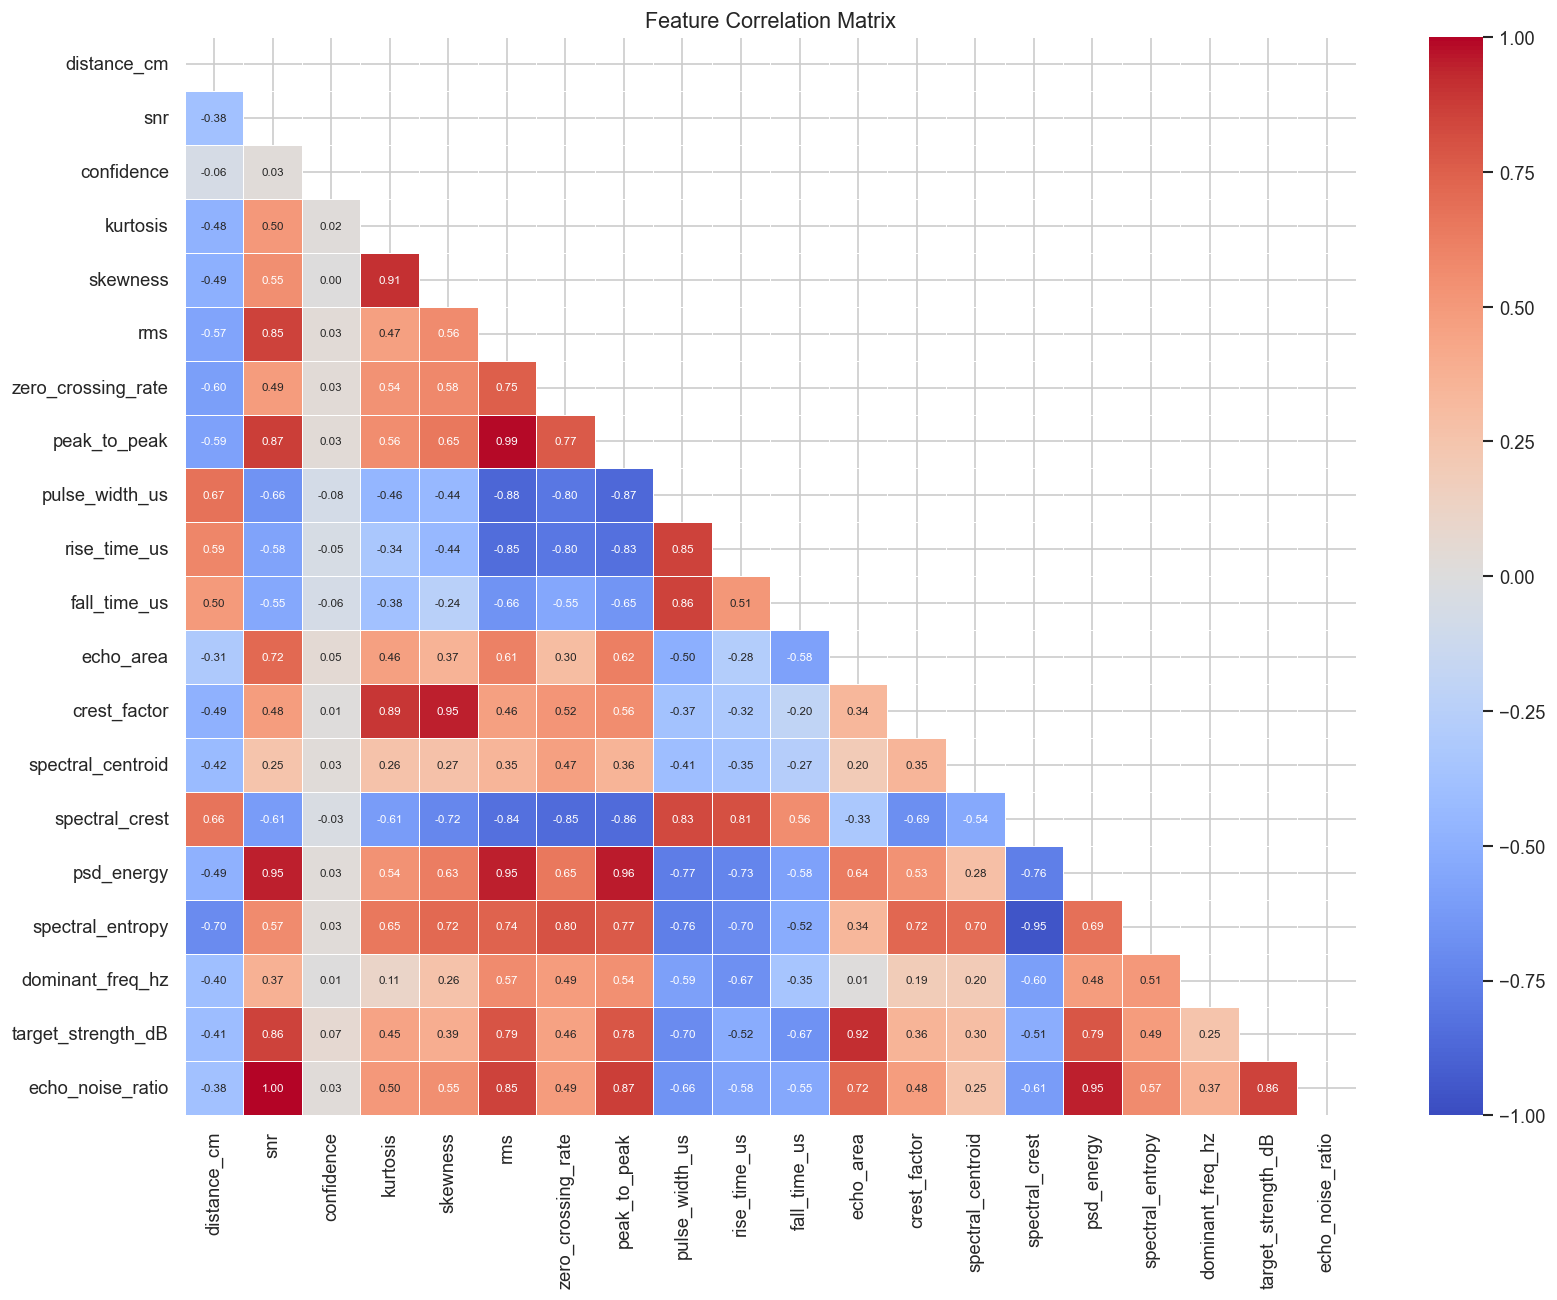


Highly correlated pairs (|r| > 0.95):
echo_noise_ratio  snr               1.000000
peak_to_peak      rms               0.991590
psd_energy        peak_to_peak      0.960893
spectral_entropy  spectral_crest    0.954261
crest_factor      skewness          0.952845


In [9]:
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Identify highly-correlated pairs (|r| > 0.95)
high_corr = (
    corr.abs()
    .where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print('\nHighly correlated pairs (|r| > 0.95):')
print(high_corr[high_corr > 0.95].to_string())

### 2.5 Per-Distance Scatter: SNR vs Echo Area

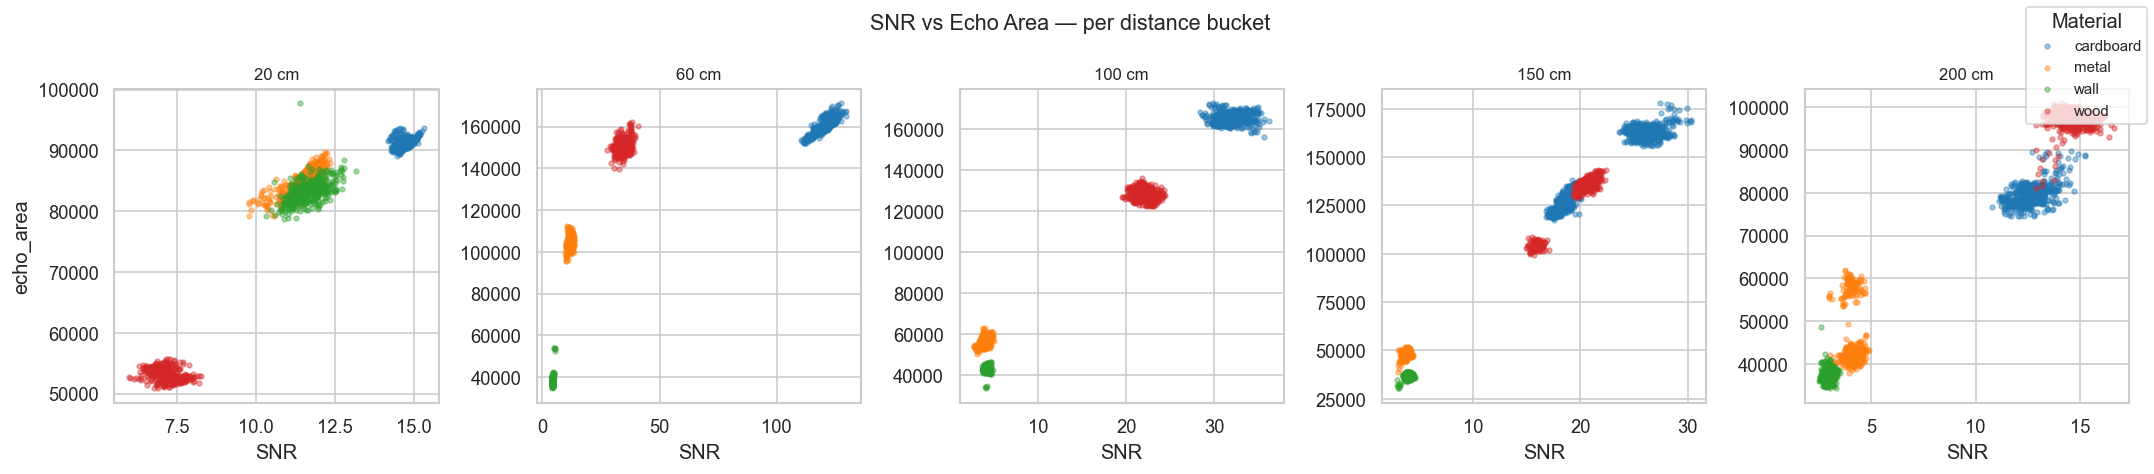

In [10]:
SAMPLE_BUCKETS = [20, 60, 100, 150, 200]

fig, axes = plt.subplots(1, len(SAMPLE_BUCKETS), figsize=(18, 4), sharey=False)
palette = dict(zip(CLASS_NAMES, sns.color_palette('tab10', len(CLASS_NAMES))))

for ax, dist in zip(axes, SAMPLE_BUCKETS):
    sub = df[df['dist_bucket'] == dist]
    for label in CLASS_NAMES:
        pts = sub[sub['label'] == label]
        ax.scatter(pts['snr'], pts['echo_area'], s=8, alpha=0.4,
                   label=label, color=palette[label])
    ax.set_title(f'{dist} cm', fontsize=10)
    ax.set_xlabel('SNR')
    ax.set_ylabel('echo_area' if dist == 20 else '')

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9, title='Material')
fig.suptitle('SNR vs Echo Area — per distance bucket', fontsize=13)
plt.tight_layout()
plt.show()

---
## Phase 3 — Feature Selection

### 3.1 Mutual Information Scores (global)

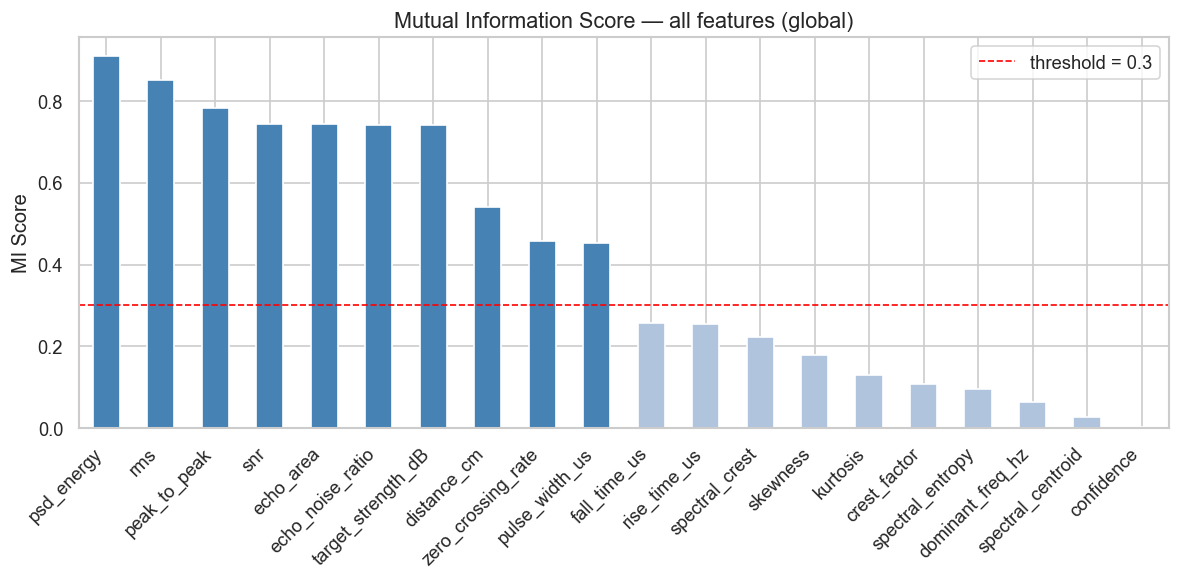


Ranked MI scores:
psd_energy            0.9095
rms                   0.8508
peak_to_peak          0.7826
snr                   0.7426
echo_area             0.7422
echo_noise_ratio      0.7420
target_strength_dB    0.7414
distance_cm           0.5404
zero_crossing_rate    0.4569
pulse_width_us        0.4518
fall_time_us          0.2565
rise_time_us          0.2558
spectral_crest        0.2227
skewness              0.1780
kurtosis              0.1309
crest_factor          0.1092
spectral_entropy      0.0959
dominant_freq_hz      0.0645
spectral_centroid     0.0276
confidence            0.0043


In [11]:
X_all = df[FEATURE_COLS]
y_all = df['label_enc']

mi_scores = mutual_info_classif(X_all, y_all, random_state=SEED)
mi_series = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if v > 0.3 else 'lightsteelblue' for v in mi_series.values]
mi_series.plot.bar(ax=ax, color=colors)
ax.axhline(0.3, color='red', linestyle='--', linewidth=1, label='threshold = 0.3')
ax.set_title('Mutual Information Score — all features (global)', fontsize=13)
ax.set_ylabel('MI Score')
ax.set_xlabel('')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nRanked MI scores:')
print(mi_series.round(4).to_string())

### 3.2 Random Forest Global Feature Importance

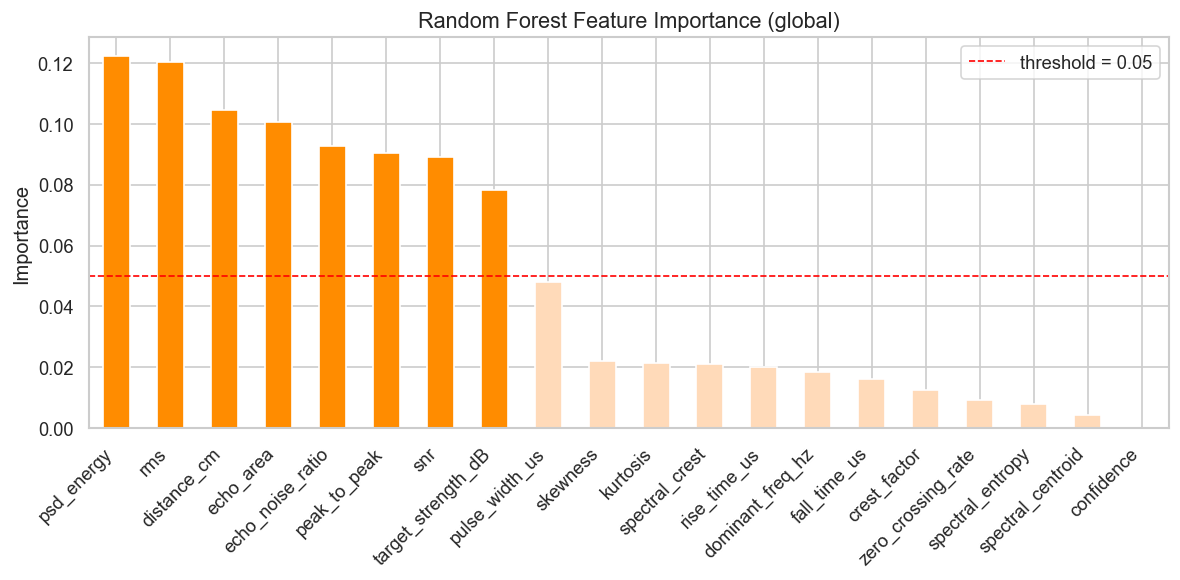


Ranked RF importances:
psd_energy            0.1223
rms                   0.1204
distance_cm           0.1044
echo_area             0.1007
echo_noise_ratio      0.0927
peak_to_peak          0.0902
snr                   0.0889
target_strength_dB    0.0781
pulse_width_us        0.0481
skewness              0.0222
kurtosis              0.0214
spectral_crest        0.0210
rise_time_us          0.0203
dominant_freq_hz      0.0186
fall_time_us          0.0163
crest_factor          0.0127
zero_crossing_rate    0.0093
spectral_entropy      0.0081
spectral_centroid     0.0043
confidence            0.0000


In [12]:
rf_fs = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_fs.fit(X_all, y_all)

rf_importance = pd.Series(rf_fs.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['darkorange' if v > 0.05 else 'peachpuff' for v in rf_importance.values]
rf_importance.plot.bar(ax=ax, color=colors)
ax.axhline(0.05, color='red', linestyle='--', linewidth=1, label='threshold = 0.05')
ax.set_title('Random Forest Feature Importance (global)', fontsize=13)
ax.set_ylabel('Importance')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nRanked RF importances:')
print(rf_importance.round(4).to_string())

### 3.3 Correlation Filter — Drop Redundant Features

In [13]:
CORR_THRESHOLD = 0.95

corr_matrix = df[FEATURE_COLS].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop the feature with lower RF importance from each highly-correlated pair
to_drop_corr = set()
for col in upper.columns:
    partners = upper.index[upper[col] > CORR_THRESHOLD].tolist()
    for partner in partners:
        # Keep the one with higher RF importance
        if rf_importance[col] >= rf_importance[partner]:
            to_drop_corr.add(partner)
        else:
            to_drop_corr.add(col)

print(f'Features dropped due to |r| > {CORR_THRESHOLD}: {sorted(to_drop_corr) or "None"}')

Features dropped due to |r| > 0.95: ['crest_factor', 'peak_to_peak', 'snr', 'spectral_entropy']


### 3.4 Final Selected Feature Set

Selected 14 features:
   1. psd_energy                   MI=0.9095  RF_imp=0.1223
   2. rms                          MI=0.8508  RF_imp=0.1204
   3. distance_cm                  MI=0.5404  RF_imp=0.1044
   4. echo_area                    MI=0.7422  RF_imp=0.1007
   5. echo_noise_ratio             MI=0.7420  RF_imp=0.0927
   6. target_strength_dB           MI=0.7414  RF_imp=0.0781
   7. pulse_width_us               MI=0.4518  RF_imp=0.0481
   8. skewness                     MI=0.1780  RF_imp=0.0222
   9. kurtosis                     MI=0.1309  RF_imp=0.0214
  10. spectral_crest               MI=0.2227  RF_imp=0.0210
  11. rise_time_us                 MI=0.2558  RF_imp=0.0203
  12. dominant_freq_hz             MI=0.0645  RF_imp=0.0186
  13. fall_time_us                 MI=0.2565  RF_imp=0.0163
  14. zero_crossing_rate           MI=0.4569  RF_imp=0.0093


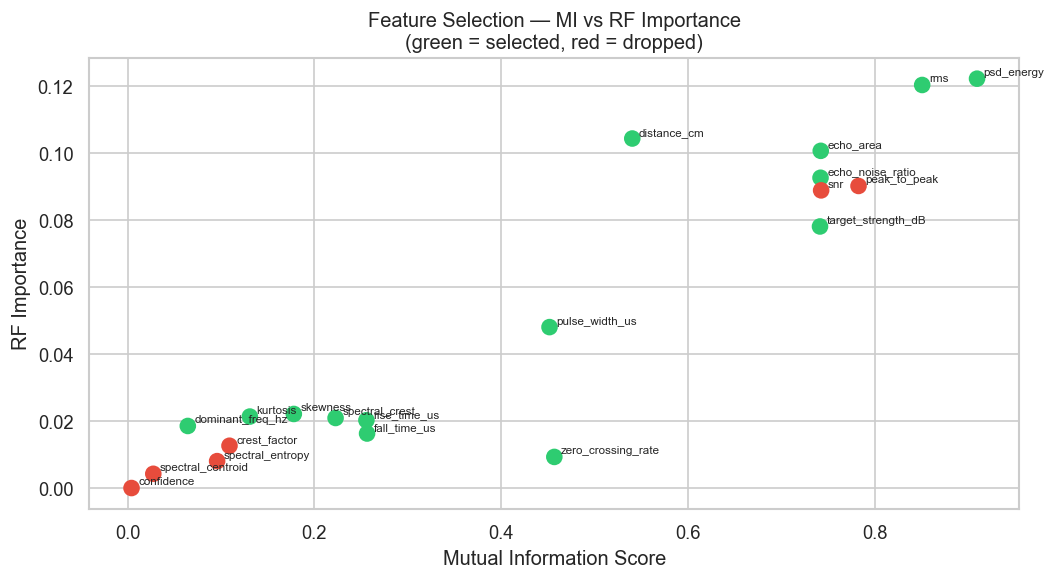

In [14]:
# Combine: keep features that pass the correlation filter AND have MI > 0.05
MI_THRESHOLD = 0.05
mi_pass = set(mi_series[mi_series > MI_THRESHOLD].index)

SELECTED_FEATURES = sorted(
    (mi_pass - to_drop_corr),
    key=lambda f: -rf_importance[f]  # rank by RF importance
)

print(f'Selected {len(SELECTED_FEATURES)} features:')
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f'  {i:2d}. {f:<28} MI={mi_series[f]:.4f}  RF_imp={rf_importance[f]:.4f}')

# Combined score plot
combined = pd.DataFrame({
    'MI_score': mi_series,
    'RF_importance': rf_importance
})
combined['selected'] = combined.index.isin(SELECTED_FEATURES)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2ecc71' if sel else '#e74c3c' for sel in combined['selected']]
ax.scatter(combined['MI_score'], combined['RF_importance'], color=colors, s=80, zorder=3)
for feat, row in combined.iterrows():
    ax.annotate(feat, (row['MI_score'], row['RF_importance']),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Mutual Information Score')
ax.set_ylabel('RF Importance')
ax.set_title('Feature Selection — MI vs RF Importance\n(green = selected, red = dropped)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Phase 4 — Per-Distance Model Training

### 4.1 Distance Buckets & Train/Test Split

In [15]:
MIN_SAMPLES_PER_BUCKET = 30
DISTANCE_BUCKETS = sorted(df['dist_bucket'].unique())

# Verify bucket sizes
bucket_sizes = df.groupby('dist_bucket').size()
valid_buckets = bucket_sizes[bucket_sizes >= MIN_SAMPLES_PER_BUCKET].index.tolist()
print(f'Total distance buckets : {len(DISTANCE_BUCKETS)}')
print(f'Valid buckets (>={MIN_SAMPLES_PER_BUCKET} samples): {valid_buckets}')
print()
print(bucket_sizes.to_string())

Total distance buckets : 19
Valid buckets (>=30 samples): [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]

dist_bucket
20     2000
30     2000
40     2002
50     2273
60     1733
70     2166
80     1876
90     1969
100    1985
110    2043
120    1953
130    2121
140    2088
150    2405
160    1589
170    1890
180    2020
190    1891
200    1996


In [16]:
# Build per-bucket train/test splits
bucket_splits = {}
for dist in valid_buckets:
    sub = df[df['dist_bucket'] == dist].copy()
    X = sub[SELECTED_FEATURES].values
    y = sub['label_enc'].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    bucket_splits[dist] = {
        'X_train': X_train_sc, 'X_test': X_test_sc,
        'y_train': y_train, 'y_test': y_test,
        'scaler': scaler
    }

print(f'Splits prepared for {len(bucket_splits)} distance buckets.')

Splits prepared for 19 distance buckets.


### 4.2 Model Comparison on a Subset of Buckets

Accuracy comparison across sample buckets:


model,GradientBoosting,RandomForest,XGBoost
distance,,,
20,1.0000,0.9975,0.9975
80,0.9973,1.0000,1.0000
140,0.9976,1.0000,1.0000
200,0.9950,0.9950,0.9925


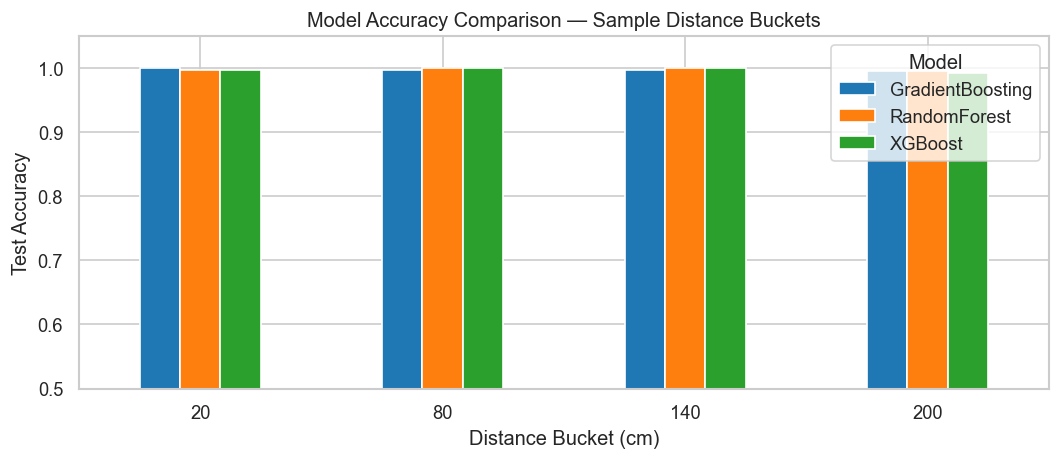

In [17]:
CANDIDATE_MODELS = {
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=SEED, verbosity=0
    ),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=SEED),
}

COMPARISON_BUCKETS = [20, 80, 140, 200]
comparison_results = []

for dist in COMPARISON_BUCKETS:
    if dist not in bucket_splits:
        continue
    split = bucket_splits[dist]
    for name, clf in CANDIDATE_MODELS.items():
        clf.fit(split['X_train'], split['y_train'])
        acc = accuracy_score(split['y_test'], clf.predict(split['X_test']))
        comparison_results.append({'distance': dist, 'model': name, 'accuracy': acc})

comp_df = pd.DataFrame(comparison_results)
pivot_comp = comp_df.pivot(index='distance', columns='model', values='accuracy').round(4)
print('Accuracy comparison across sample buckets:')
display(pivot_comp)

fig, ax = plt.subplots(figsize=(9, 4))
pivot_comp.plot(kind='bar', ax=ax)
ax.set_title('Model Accuracy Comparison — Sample Distance Buckets', fontsize=12)
ax.set_xlabel('Distance Bucket (cm)')
ax.set_ylabel('Test Accuracy')
ax.set_ylim(0.5, 1.05)
ax.legend(title='Model')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.3 Train Best Model Across All Distance Buckets

In [18]:
# Pick the model with the highest mean accuracy from comparison
best_model_name = comp_df.groupby('model')['accuracy'].mean().idxmax()
print(f'Best model: {best_model_name} (mean acc = {comp_df.groupby("model")["accuracy"].mean()[best_model_name]:.4f})')

def make_model(name):
    if name == 'RandomForest':
        return RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)
    elif name == 'XGBoost':
        return XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            use_label_encoder=False, eval_metric='mlogloss',
            random_state=SEED, verbosity=0
        )
    else:
        return GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=SEED)

Best model: RandomForest (mean acc = 0.9981)


In [19]:
trained_models  = {}
all_results     = []
all_reports     = {}

for dist in valid_buckets:
    split = bucket_splits[dist]
    clf = make_model(best_model_name)
    clf.fit(split['X_train'], split['y_train'])
    y_pred = clf.predict(split['X_test'])

    acc = accuracy_score(split['y_test'], y_pred)
    report = classification_report(
        split['y_test'], y_pred,
        target_names=CLASS_NAMES, output_dict=True
    )
    trained_models[dist] = clf
    all_reports[dist] = report
    all_results.append({
        'distance': dist,
        'accuracy': acc,
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
    })
    print(f'[{dist:>3}cm]  acc={acc:.4f}  macro_f1={report["macro avg"]["f1-score"]:.4f}')

results_df = pd.DataFrame(all_results)
print(f'\nOverall weighted accuracy: {results_df["accuracy"].mean():.4f}')

[ 20cm]  acc=0.9975  macro_f1=0.9975
[ 30cm]  acc=1.0000  macro_f1=1.0000
[ 40cm]  acc=1.0000  macro_f1=1.0000
[ 50cm]  acc=1.0000  macro_f1=1.0000
[ 60cm]  acc=1.0000  macro_f1=1.0000
[ 70cm]  acc=1.0000  macro_f1=1.0000
[ 80cm]  acc=1.0000  macro_f1=1.0000
[ 90cm]  acc=1.0000  macro_f1=1.0000
[100cm]  acc=1.0000  macro_f1=1.0000
[110cm]  acc=0.9927  macro_f1=0.9927
[120cm]  acc=1.0000  macro_f1=1.0000
[130cm]  acc=0.9976  macro_f1=0.9976
[140cm]  acc=1.0000  macro_f1=1.0000
[150cm]  acc=1.0000  macro_f1=1.0000
[160cm]  acc=1.0000  macro_f1=1.0000
[170cm]  acc=1.0000  macro_f1=1.0000
[180cm]  acc=1.0000  macro_f1=1.0000
[190cm]  acc=1.0000  macro_f1=1.0000
[200cm]  acc=0.9950  macro_f1=0.9950

Overall weighted accuracy: 0.9991


---
## Phase 5 — Evaluation

### 5.1 Accuracy & F1 vs Distance

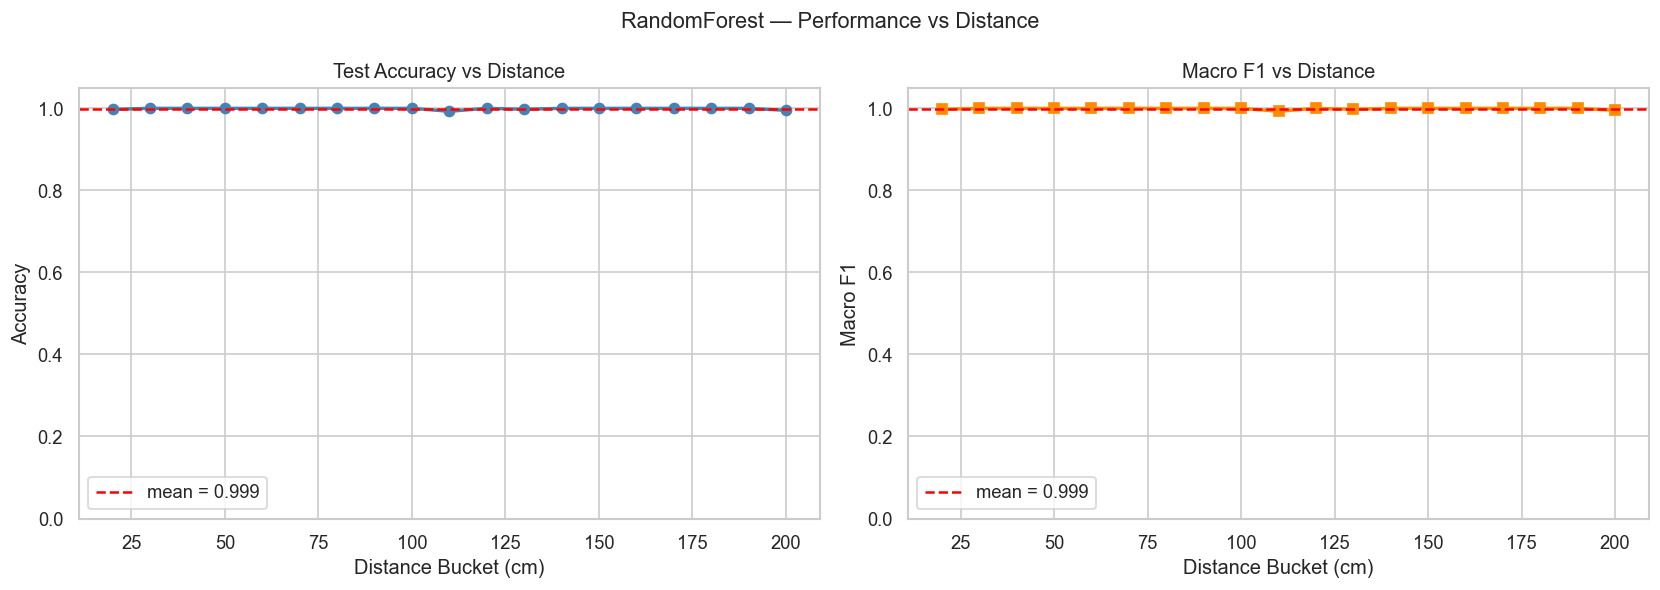

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['distance'], results_df['accuracy'], 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Test Accuracy vs Distance', fontsize=12)
axes[0].set_xlabel('Distance Bucket (cm)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(results_df['accuracy'].mean(), color='red', linestyle='--',
                label=f'mean = {results_df["accuracy"].mean():.3f}')
axes[0].legend()

axes[1].plot(results_df['distance'], results_df['macro_f1'], 's-', color='darkorange', linewidth=2)
axes[1].set_title('Macro F1 vs Distance', fontsize=12)
axes[1].set_xlabel('Distance Bucket (cm)')
axes[1].set_ylabel('Macro F1')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(results_df['macro_f1'].mean(), color='red', linestyle='--',
                label=f'mean = {results_df["macro_f1"].mean():.3f}')
axes[1].legend()

plt.suptitle(f'{best_model_name} — Performance vs Distance', fontsize=13)
plt.tight_layout()
plt.show()

### 5.2 Per-Class F1 Heatmap (across distances)

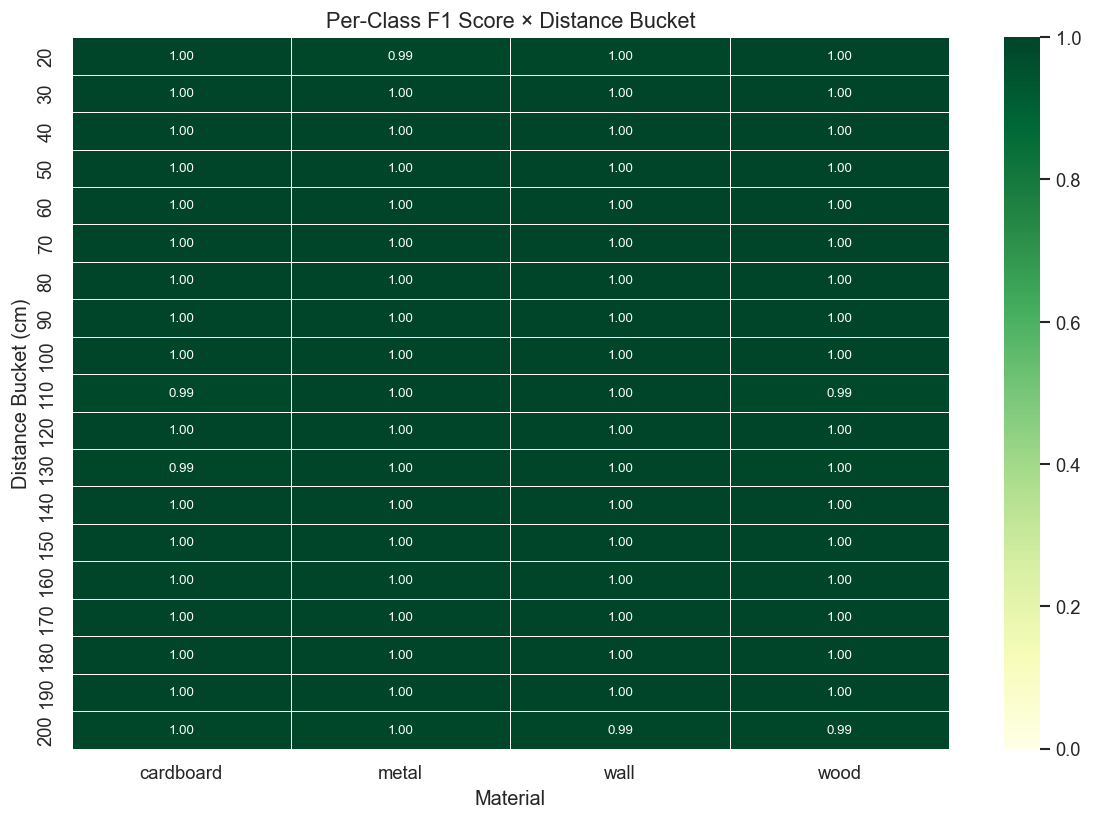

In [21]:
class_f1 = pd.DataFrame(
    {dist: {cls: all_reports[dist][cls]['f1-score'] for cls in CLASS_NAMES}
     for dist in valid_buckets}
).T  # rows = distances, cols = classes

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    class_f1, annot=True, fmt='.2f', cmap='YlGn',
    vmin=0, vmax=1, linewidths=0.3,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Per-Class F1 Score × Distance Bucket', fontsize=13)
ax.set_xlabel('Material')
ax.set_ylabel('Distance Bucket (cm)')
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrices — Select Distances

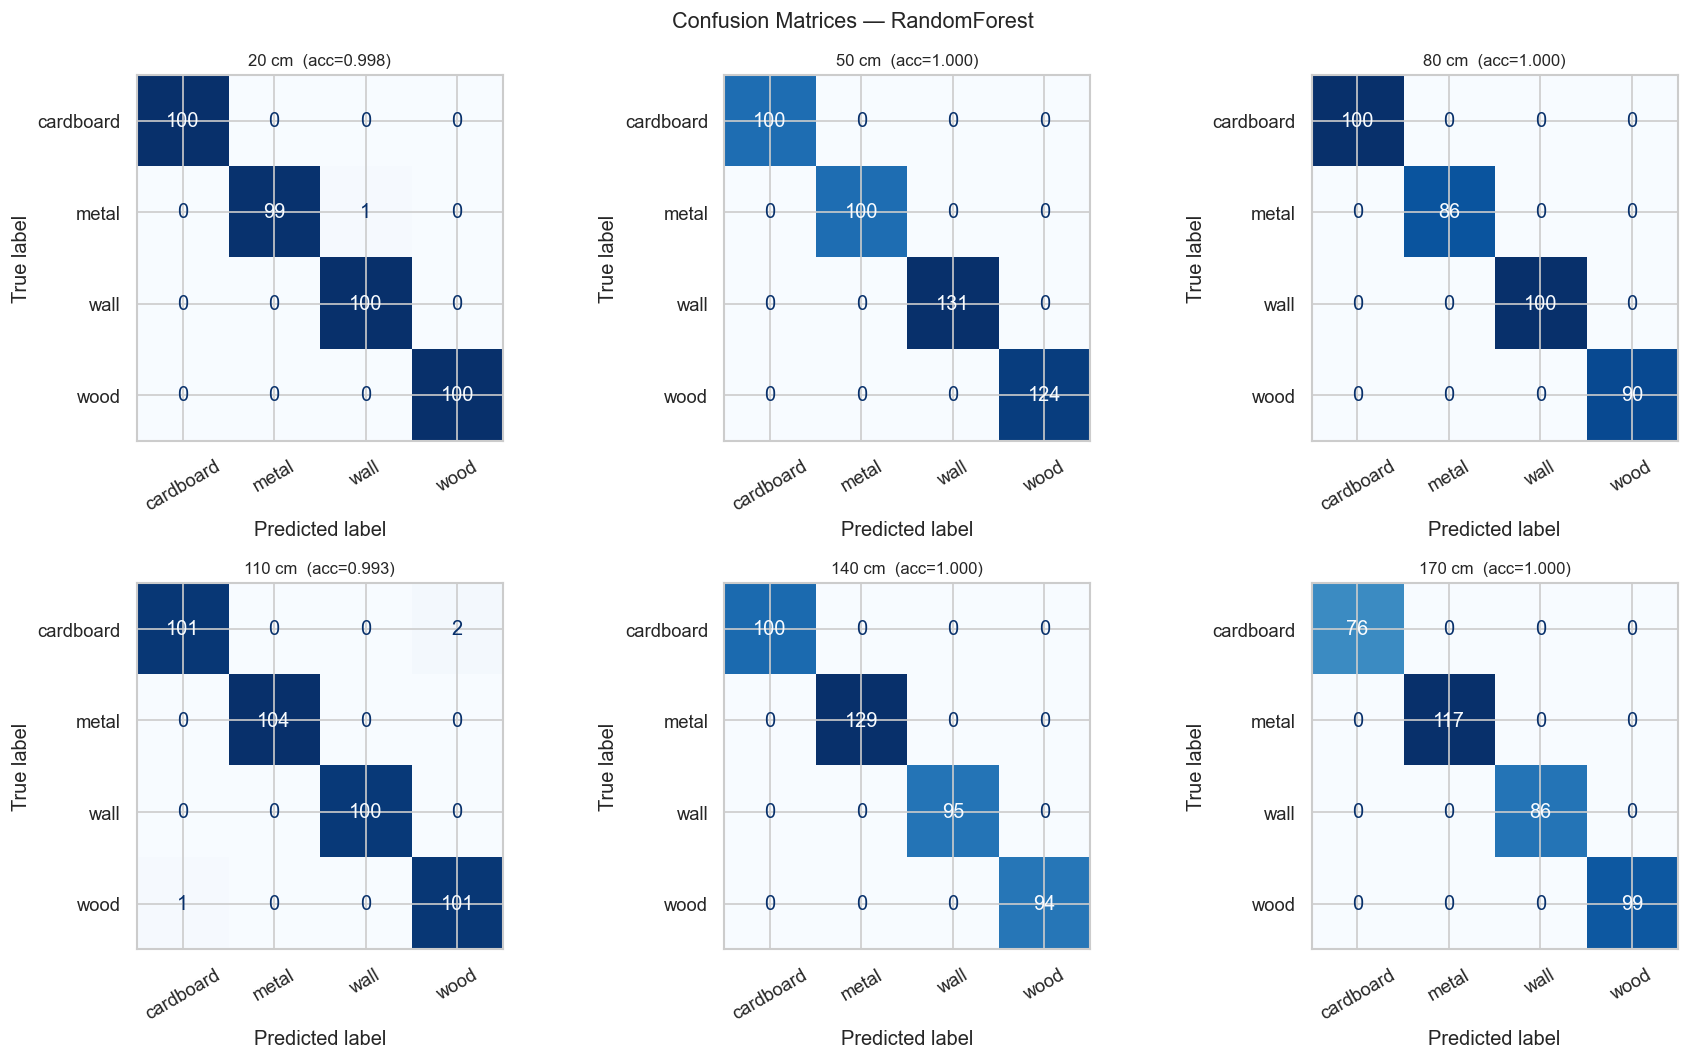

In [22]:
PLOT_BUCKETS = valid_buckets[::max(1, len(valid_buckets)//6)][:6]  # up to 6 representative buckets

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, dist in zip(axes, PLOT_BUCKETS):
    split = bucket_splits[dist]
    y_pred = trained_models[dist].predict(split['X_test'])
    cm = confusion_matrix(split['y_test'], y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{dist} cm  (acc={accuracy_score(split["y_test"], y_pred):.3f})', fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

for j in range(len(PLOT_BUCKETS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f'Confusion Matrices — {best_model_name}', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 Hard Cases — Most Confused Class Pairs

Most confused class pairs (total misclassifications across all distances):


,count
pair,
cardboard → wood,3
wood → cardboard,2
metal → wall,1
wall → metal,1


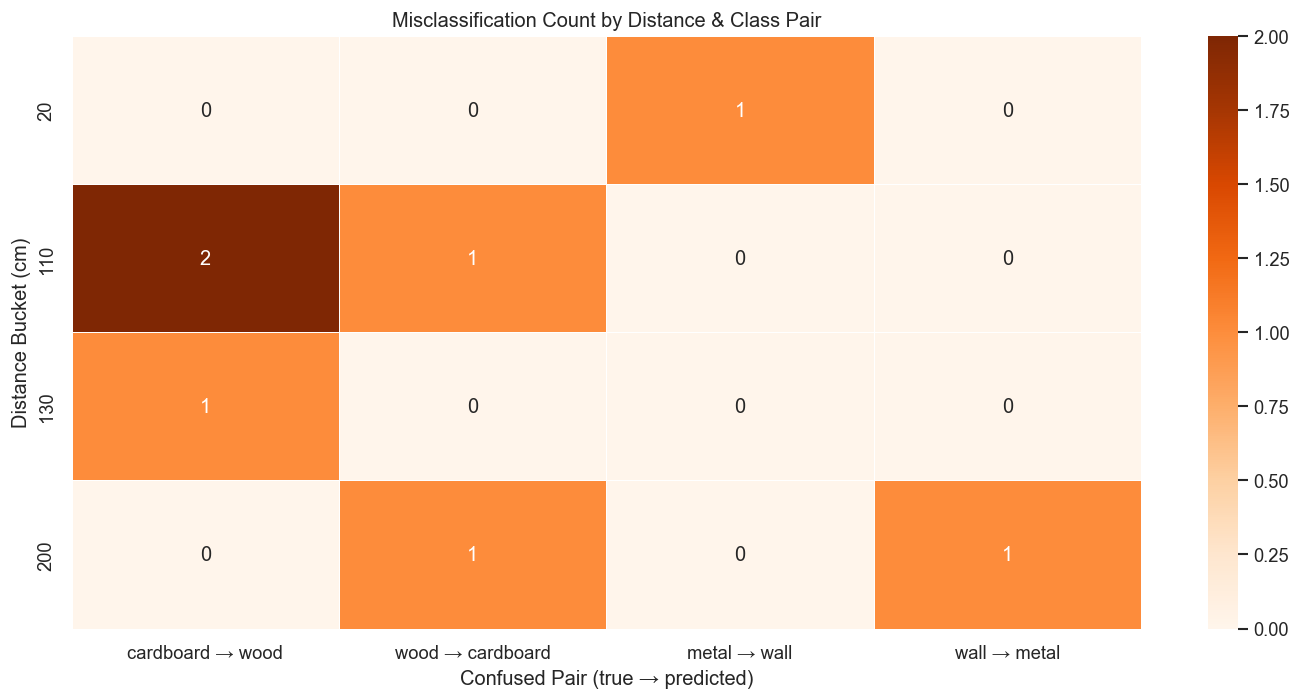

In [23]:
confused_pairs = []

for dist in valid_buckets:
    split = bucket_splits[dist]
    y_pred = trained_models[dist].predict(split['X_test'])
    cm = confusion_matrix(split['y_test'], y_pred)
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            if i != j and cm[i, j] > 0:
                confused_pairs.append({
                    'distance': dist,
                    'true': CLASS_NAMES[i],
                    'predicted': CLASS_NAMES[j],
                    'count': cm[i, j]
                })

confused_df = pd.DataFrame(confused_pairs)
if not confused_df.empty:
    confused_df['pair'] = confused_df['true'] + ' → ' + confused_df['predicted']
    pair_summary = confused_df.groupby('pair')['count'].sum().sort_values(ascending=False)
    print('Most confused class pairs (total misclassifications across all distances):')
    display(pair_summary.head(10).to_frame())

    # Heatmap of confusion pair × distance
    pivot_confused = confused_df.pivot_table(
        index='distance', columns='pair', values='count', aggfunc='sum', fill_value=0
    )
    top_pairs = pair_summary.head(6).index.tolist()
    pivot_confused = pivot_confused[[p for p in top_pairs if p in pivot_confused.columns]]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(pivot_confused, annot=True, fmt='d', cmap='Oranges', linewidths=0.3, ax=ax)
    ax.set_title('Misclassification Count by Distance & Class Pair', fontsize=12)
    ax.set_xlabel('Confused Pair (true → predicted)')
    ax.set_ylabel('Distance Bucket (cm)')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassifications found!')

### 5.5 Summary Table

In [24]:
summary = results_df.copy().set_index('distance')
summary.columns = ['Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']

print(f'=== {best_model_name} — Full Results Summary ===')
display(summary.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}'))

print(f'\nMean Accuracy         : {summary["Accuracy"].mean():.4f}')
print(f'Mean Macro F1         : {summary["Macro F1"].mean():.4f}')
print(f'Worst Accuracy        : {summary["Accuracy"].min():.4f} @ {summary["Accuracy"].idxmin()} cm')
print(f'Best  Accuracy        : {summary["Accuracy"].max():.4f} @ {summary["Accuracy"].idxmax()} cm')

=== RandomForest — Full Results Summary ===


,Accuracy,Macro F1,Macro Precision,Macro Recall
distance,,,,
20,0.9975,0.9975,0.9975,0.9975
30,1.0000,1.0000,1.0000,1.0000
40,1.0000,1.0000,1.0000,1.0000
50,1.0000,1.0000,1.0000,1.0000
60,1.0000,1.0000,1.0000,1.0000
70,1.0000,1.0000,1.0000,1.0000
80,1.0000,1.0000,1.0000,1.0000
90,1.0000,1.0000,1.0000,1.0000
100,1.0000,1.0000,1.0000,1.0000



Mean Accuracy         : 0.9991
Mean Macro F1         : 0.9991
Worst Accuracy        : 0.9927 @ 110 cm
Best  Accuracy        : 1.0000 @ 30 cm


---
## Phase 6 — Model Persistence

In [25]:
os.makedirs('models', exist_ok=True)
os.makedirs('scalers', exist_ok=True)

for dist in valid_buckets:
    joblib.dump(trained_models[dist],       f'models/model_{dist}cm.pkl')
    joblib.dump(bucket_splits[dist]['scaler'], f'scalers/scaler_{dist}cm.pkl')

# Save metadata
metadata = {
    'model_type': best_model_name,
    'classes': CLASS_NAMES,
    'label_encoding': {cls: int(le.transform([cls])[0]) for cls in CLASS_NAMES},
    'features': SELECTED_FEATURES,
    'distance_buckets': valid_buckets,
    'n_models': len(valid_buckets)
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved {len(valid_buckets)} models to models/')
print(f'Saved {len(valid_buckets)} scalers to scalers/')
print(f'Saved metadata to models/metadata.json')
print()
print('metadata.json preview:')
print(json.dumps(metadata, indent=2))

Saved 19 models to models/
Saved 19 scalers to scalers/
Saved metadata to models/metadata.json

metadata.json preview:
{
  "model_type": "RandomForest",
  "classes": [
    "cardboard",
    "metal",
    "wall",
    "wood"
  ],
  "label_encoding": {
    "cardboard": 0,
    "metal": 1,
    "wall": 2,
    "wood": 3
  },
  "features": [
    "psd_energy",
    "rms",
    "distance_cm",
    "echo_area",
    "echo_noise_ratio",
    "target_strength_dB",
    "pulse_width_us",
    "skewness",
    "kurtosis",
    "spectral_crest",
    "rise_time_us",
    "dominant_freq_hz",
    "fall_time_us",
    "zero_crossing_rate"
  ],
  "distance_buckets": [
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90,
    100,
    110,
    120,
    130,
    140,
    150,
    160,
    170,
    180,
    190,
    200
  ],
  "n_models": 19
}


---
## Quick Inference Helper

Template for using the saved models in deployment.

In [26]:
def predict_material(features_dict: dict, distance_cm: float) -> str:
    """
    Predict material from a single ultrasonic measurement.

    Parameters
    ----------
    features_dict : dict   Keys are feature names from SELECTED_FEATURES.
    distance_cm   : float  Measured distance in cm (will be rounded to nearest 10cm bucket).

    Returns
    -------
    str  Predicted material label.
    """
    with open('models/metadata.json') as f:
        meta = json.load(f)

    bucket = int(round(distance_cm / 10) * 10)
    if bucket not in meta['distance_buckets']:
        bucket = min(meta['distance_buckets'], key=lambda b: abs(b - bucket))

    model  = joblib.load(f'models/model_{bucket}cm.pkl')
    scaler = joblib.load(f'scalers/scaler_{bucket}cm.pkl')

    x = np.array([[features_dict[f] for f in meta['features']]])
    x_scaled = scaler.transform(x)
    pred_enc = model.predict(x_scaled)[0]
    return meta['classes'][pred_enc]


# Smoke-test: pick a real row from the dataset
test_row = df[df['dist_bucket'] == 80].iloc[0]
test_features = {f: test_row[f] for f in SELECTED_FEATURES}
prediction = predict_material(test_features, test_row['distance_cm'])
print(f"True label  : {test_row['label']}")
print(f"Predicted   : {prediction}")
print(f"Match       : {test_row['label'] == prediction}")

True label  : cardboard
Predicted   : cardboard
Match       : True


In [29]:
def predict_material(features_dict: dict, distance_cm: float) -> str:
    """
    Predict material from a single ultrasonic measurement.

    Parameters
    ----------
    features_dict : dict   Keys are feature names from SELECTED_FEATURES.
    distance_cm   : float  Measured distance in cm (will be rounded to nearest 10cm bucket).

    Returns
    -------
    str  Predicted material label.
    """
    with open('models/metadata.json') as f:
        meta = json.load(f)

    bucket = int(round(distance_cm / 10) * 10)
    if bucket not in meta['distance_buckets']:
        bucket = min(meta['distance_buckets'], key=lambda b: abs(b - bucket))

    model  = joblib.load(f'models/model_{bucket}cm.pkl')
    scaler = joblib.load(f'scalers/scaler_{bucket}cm.pkl')

    x = np.array([[features_dict[f] for f in meta['features']]])
    x_scaled = scaler.transform(x)
    pred_enc = model.predict(x_scaled)[0]
    return meta['classes'][pred_enc]


# Smoke-test: pick a real row from the dataset
test_row = df[df['dist_bucket'] == 80].iloc[0]
test_features = {f: test_row[f] for f in SELECTED_FEATURES}
prediction = predict_material(test_features, test_row['distance_cm'])
print(f"True label  : {test_row['label']}")
print(f"Predicted   : {prediction}")
print(f"Match       : {test_row['label'] == prediction}")

True label  : cardboard
Predicted   : cardboard
Match       : True


# Testing

In [30]:
import joblib, json, numpy as np

# Load metadata
with open('models/metadata.json') as f:
    meta = json.load(f)

print("Classes:", meta['classes'])
print("Features needed:", meta['features'])
print("Available distances:", meta['distance_buckets'])

# Replace these values with real sensor readings
my_sample = {
    'psd_energy':         490132416.0,
    'rms':                6381.15,
    'distance_cm':        20.0,
    'echo_area':          91266.2,
    'echo_noise_ratio':   15.13,
    'target_strength_dB': 23.6,
    'pulse_width_us':     166.65,
    'skewness':           0.6591,
    'kurtosis':          -0.7569,
    'spectral_crest':     8.106,
    'rise_time_us':       33.33,
    'dominant_freq_hz':   703.2,
    'fall_time_us':       99.99,
    'zero_crossing_rate': 0.1333,
}

result = predict_material(my_sample, distance_cm=20.0)
print("Predicted material:", result)


Classes: ['cardboard', 'metal', 'wall', 'wood']
Features needed: ['psd_energy', 'rms', 'distance_cm', 'echo_area', 'echo_noise_ratio', 'target_strength_dB', 'pulse_width_us', 'skewness', 'kurtosis', 'spectral_crest', 'rise_time_us', 'dominant_freq_hz', 'fall_time_us', 'zero_crossing_rate']
Available distances: [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
Predicted material: cardboard


In [31]:
from sklearn.metrics import classification_report
import pandas as pd

# Take 50 random rows per class from the original dataset
holdout = df.groupby('label').sample(n=50, random_state=99)

correct = 0
records = []
for _, row in holdout.iterrows():
    feats = {f: row[f] for f in SELECTED_FEATURES}
    pred  = predict_material(feats, row['distance_cm'])
    records.append({'true': row['label'], 'pred': pred})
    correct += int(pred == row['label'])

ho_df = pd.DataFrame(records)
print(f"Holdout accuracy: {correct}/{len(holdout)} = {correct/len(holdout):.2%}\n")
print(classification_report(ho_df['true'], ho_df['pred']))


Holdout accuracy: 199/200 = 99.50%

              precision    recall  f1-score   support

   cardboard       1.00      0.98      0.99        50
       metal       1.00      1.00      1.00        50
        wall       1.00      1.00      1.00        50
        wood       0.98      1.00      0.99        50

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

